---
*IIT Short Course - Python Programming Lectures*  
*Instructor: Md Mostafizur Rahaman*  
*Email: bsse1320@iit.du.ac.bd*  

## Lecture 19: Linear Regression and Correlation Analysis

Datasets: Study Hours and Exam Scores for prediction


### Install Libraries

In [1]:
!python -m pip install numpy matplotlib seaborn pandas scikit-learn


## Common Classification Models

There are several popular models used for classification tasks:

**Decision Tree Classifier** - splits data into branches based on feature values.

**Random Forest Classifier** - ensemble of decision trees for more robust predictions.

**K-Nearest Neighbors (KNN)** - predicts class based on the majority class of nearest neighbors.

**Support Vector Machine (SVM)** - finds the optimal hyperplane to separate classes.

**Logistic Regression** - despite the name, used for binary classification.

**Naive Bayes** - probabilistic model based on Bayes' theorem.

**Neural Networks** - can model complex relationships for multi-class classification tasks.

In [2]:
from sklearn.preprocessing import LabelEncoder

colors = ['Red', 'Green', 'Blue', 'Red']
le = LabelEncoder()
encoded = le.fit_transform(colors)
print(encoded)  # Output: [0 1 2 0]

[2 1 0 2]


In [3]:
import numpy as np
from sklearn.preprocessing import OneHotEncoder

colors = np.array(['Red', 'Green', 'Blue', 'Red']).reshape(-1, 1)
ohe = OneHotEncoder(sparse_output=False)
encoded = ohe.fit_transform(colors)
print(encoded)

[[0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]]


In [4]:
import pandas as pd

# Load the dataset
df = pd.read_csv("diamonds.csv")

# Display first few rows
print(df.head())

# Show dataset info to identify categorical columns
print(df.info())

   rownames  carat      cut color clarity  depth  table  price     x     y  \
0         1   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98   
1         2   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84   
2         3   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07   
3         4   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23   
4         5   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35   

      z  
0  2.43  
1  2.31  
2  2.31  
3  2.63  
4  2.75  
<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   rownames  53940 non-null  int64  
 1   carat     53940 non-null  float64
 2   cut       53940 non-null  str    
 3   color     53940 non-null  str    
 4   clarity   53940 non-null  str    
 5   depth     53940 non-null  float64
 6   table     53940 non-null  float64
 7   price     53940 n

In [5]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Apply label encoding on 'color'
label_encoder = LabelEncoder()
df["color"] = label_encoder.fit_transform(df["color"])

# Display encoded dataframe
print(df.head())

# Apply one-hot encoding on 'clarity' using pandas get_dummies
df = pd.get_dummies(df, columns=["clarity"])

# Display encoded dataframe
print(df.head())

   rownames  carat      cut  color clarity  depth  table  price     x     y  \
0         1   0.23    Ideal      1     SI2   61.5   55.0    326  3.95  3.98   
1         2   0.21  Premium      1     SI1   59.8   61.0    326  3.89  3.84   
2         3   0.23     Good      1     VS1   56.9   65.0    327  4.05  4.07   
3         4   0.29  Premium      5     VS2   62.4   58.0    334  4.20  4.23   
4         5   0.31     Good      6     SI2   63.3   58.0    335  4.34  4.35   

      z  
0  2.43  
1  2.31  
2  2.31  
3  2.63  
4  2.75  
   rownames  carat      cut  color  depth  table  price     x     y     z  \
0         1   0.23    Ideal      1   61.5   55.0    326  3.95  3.98  2.43   
1         2   0.21  Premium      1   59.8   61.0    326  3.89  3.84  2.31   
2         3   0.23     Good      1   56.9   65.0    327  4.05  4.07  2.31   
3         4   0.29  Premium      5   62.4   58.0    334  4.20  4.23  2.63   
4         5   0.31     Good      6   63.3   58.0    335  4.34  4.35  2.75   

  

In [6]:
# Check for null values
print(df.isna().sum())  # diamonds dataset has no null values

# Drop if there exists any duplicate
df = df.drop_duplicates()

rownames        0
carat           0
cut             0
color           0
depth           0
table           0
price           0
x               0
y               0
z               0
clarity_I1      0
clarity_IF      0
clarity_SI1     0
clarity_SI2     0
clarity_VS1     0
clarity_VS2     0
clarity_VVS1    0
clarity_VVS2    0
dtype: int64


In [7]:
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Step 1: Define Features and Target
y = df["cut"]                  # Target variable: diamond cut
X = df.drop("cut", axis=1)     # Features: all columns except 'cut'

# Step 2: Train-Test Split (80% training and 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 3: Train the Decision Tree Classifier
classifier = DecisionTreeClassifier()  # Initialize Decision Tree Classifier
classifier.fit(X_train, y_train)       # Train the model

# Step 4: Make Predictions
y_pred = classifier.predict(X_test)    # Predict the cut on test data

# Step 5: Evaluate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)           # Output: 0.7155 (approx)

Accuracy: 0.71403411197627


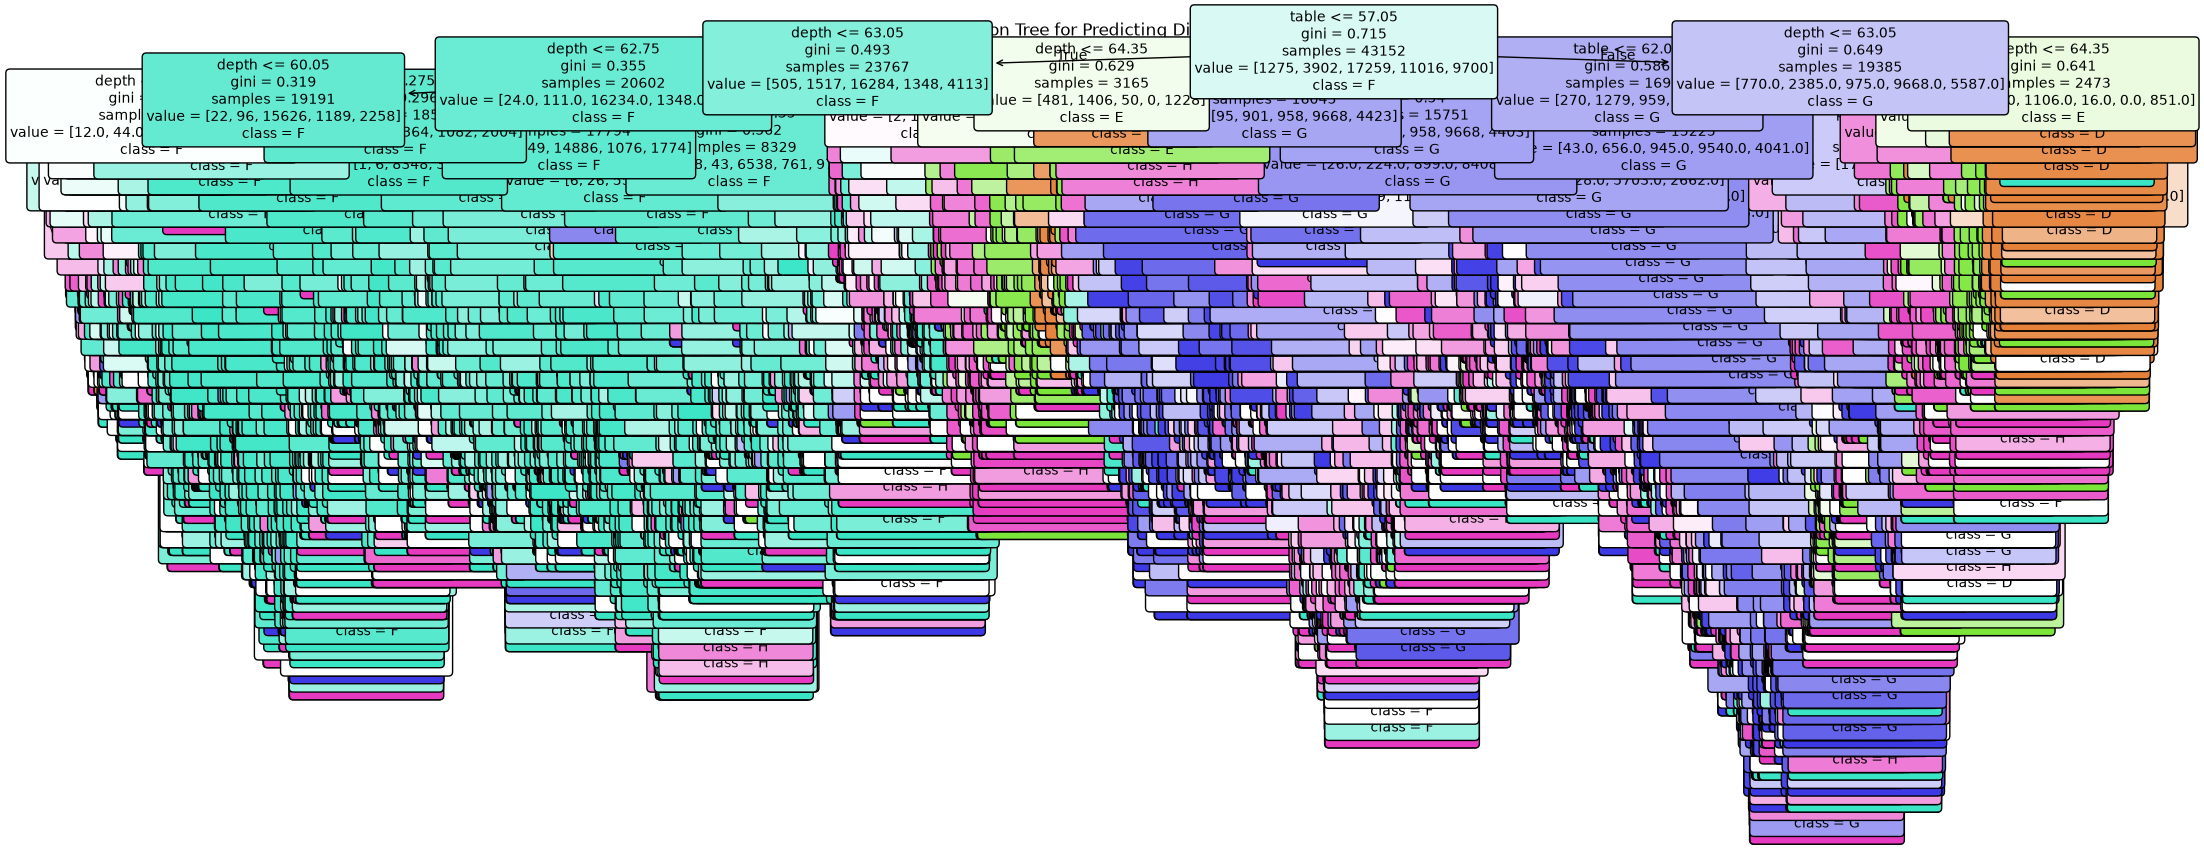

In [8]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(25, 10))
plot_tree(
    classifier,
    filled=True,
    feature_names=X.columns,
    class_names=label_encoder.classes_,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree for Predicting Diamond Cut")
plt.savefig("tree-plot.png")  # Save the plot as an image
plt.show()

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Initialize Random Forest Classifier
classifier = RandomForestClassifier()  # Only change in this line

# Train the model
classifier.fit(X_train, y_train)

# Make predictions
y_pred = classifier.predict(X_test)

# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)  # Output: 0.7789 (approx)

Accuracy: 0.7777159807193178


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

# Set style and seed for consistency
plt.style.use('default')
np.random.seed(42)


### 1. **Linear Regression** - Predicting the Future

**Linear Regression** is a simple way to **predict a number** (like an exam score) based on another number (like study hours). 

**How it works:**
- It draws the **"best-fitting" straight line** through your data points.
- The formula is: **`Y = mX + b`**
    - **`Y`**: What you want to predict (**Target**)
    - **`X`**: What you already know (**Feature**)
    - **`m`**: The **Slope** (how much Y changes for each X)
    - **`b`**: The **Starting Point** (where the line starts)

**When to use it?**
- When you want to **forecast** trends or **predict** outcomes.
- E.g., Predicting **Score** based on **Study Hours**.

**Demo:** Predicting Exam Scores based on Study Hours


In [11]:
# Create a simple dataset: Study hours vs Exam scores
study_hours = [2, 3, 4, 5, 6, 7, 8, 9, 10, 12]  # Independent Variable (X)
exam_scores = [45, 55, 65, 70, 75, 80, 85, 88, 90, 95]  # Dependent Variable (y)

# Create DataFrame
study_df = pd.DataFrame({
    'study_hours': study_hours,
    'exam_score': exam_scores
})

print("Dataset: Study Hours vs Exam Scores")
print("-" * 35)
print(study_df)


Dataset: Study Hours vs Exam Scores
-----------------------------------
   study_hours  exam_score
0            2          45
1            3          55
2            4          65
3            5          70
4            6          75
5            7          80
6            8          85
7            9          88
8           10          90
9           12          95


In [12]:
# Step 1: Prepare the data
X = study_df['study_hours'].values.reshape(-1, 1)  # Study hours (independent variable) [reshape(-1, 1) transforms an array into a single column (vector).]
y = study_df['exam_score'].values  # Exam scores (dependent variable)

print(f"X (Study Hours): {X}")
print(f"y (Exam Scores): {y}")


X (Study Hours): [[ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]
 [12]]
y (Exam Scores): [45 55 65 70 75 80 85 88 90 95]


In [13]:
# Step 2: Create and train the model

model = LinearRegression()
model.fit(X, y)

print("✅ Model trained successfully!")

✅ Model trained successfully!


In [14]:
# Step 3: Get the line parameters (Equation)
slope = model.coef_[0]
intercept = model.intercept_

print(f"📊 The Resulting Equation:")
print(f"   Exam Score = {intercept:.2f} + ({slope:.2f} x Study Hours)")

print(f"\n✨ In Simple Terms:")
print(f"   - Starting Score: {intercept:.1f} (if study hours = 0)")
print(f"   - Boost: Each hour of study adds +{slope:.1f} points!")


📊 The Resulting Equation:
   Exam Score = 42.64 + (4.87 x Study Hours)

✨ In Simple Terms:
   - Starting Score: 42.6 (if study hours = 0)
   - Boost: Each hour of study adds +4.9 points!


In [15]:
# Step 4: Make predictions

y_pred = model.predict(X)

print("Predicted scores for our data:")
for hours, actual, predicted in zip(study_hours, exam_scores, y_pred):
    print(f"Study {hours}h: Actual={actual}, Predicted={predicted:.1f}")

Predicted scores for our data:
Study 2h: Actual=45, Predicted=52.4
Study 3h: Actual=55, Predicted=57.3
Study 4h: Actual=65, Predicted=62.1
Study 5h: Actual=70, Predicted=67.0
Study 6h: Actual=75, Predicted=71.9
Study 7h: Actual=80, Predicted=76.7
Study 8h: Actual=85, Predicted=81.6
Study 9h: Actual=88, Predicted=86.5
Study 10h: Actual=90, Predicted=91.4
Study 12h: Actual=95, Predicted=101.1


In [16]:
# Step 5: Check Accuracy (R-squared)
r_squared = model.score(X, y)

print(f"📈 Model Accuracy (R-squared): {r_squared*100:.1f}%")
print("-" * 40)
print(f"This means {r_squared*100:.1f}% of the change in scores is")
print("explained by study hours. Higher is better!")


📈 Model Accuracy (R-squared): 93.6%
----------------------------------------
This means 93.6% of the change in scores is
explained by study hours. Higher is better!


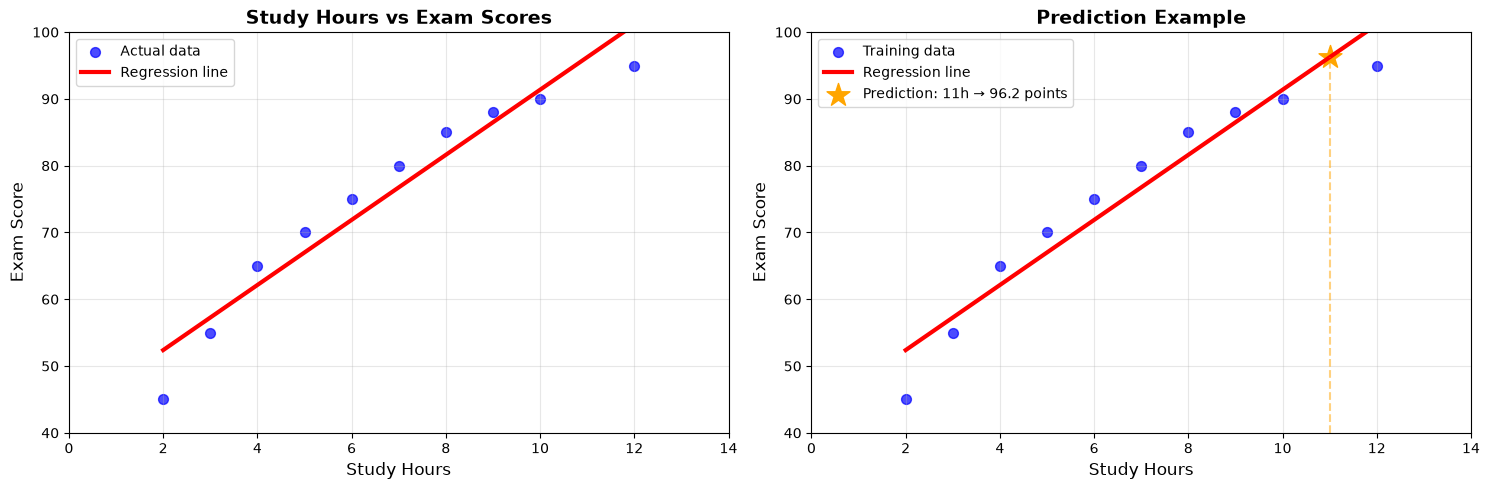

In [17]:
# Step 6: Visualize the results
plt.figure(figsize=(15, 5))

# Plot 1: Data points and regression line
plt.subplot(1, 2, 1)

plt.scatter(X, y, alpha=0.7, color='blue', s=50, label='Actual data')
plt.plot(X, y_pred, color='red', linewidth=3, label='Regression line')

plt.title('Study Hours vs Exam Scores', fontsize=14, fontweight='bold')
plt.xlabel('Study Hours', fontsize=12)
plt.ylabel('Exam Score', fontsize=12)

plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 14)
plt.ylim(40, 100)

# Plot 2: Prediction example
plt.subplot(1, 2, 2)
plt.scatter(X, y, alpha=0.7, color='blue', s=50, label='Training data')
plt.plot(X, y_pred, color='red', linewidth=3, label='Regression line')

# Add new prediction point
new_hours = 11
predicted_new = model.predict([[new_hours]])[0]

# Plot new prediction point
plt.scatter([new_hours], [predicted_new], color='orange', s=300, marker='*', label=f'Prediction: {new_hours}h → {predicted_new:.1f} points')
plt.plot([new_hours, new_hours], [40, predicted_new], 'orange', linestyle='--', alpha=0.5)

plt.title('Prediction Example', fontsize=14, fontweight='bold')
plt.xlabel('Study Hours', fontsize=12)
plt.ylabel('Exam Score', fontsize=12)

plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 14)
plt.ylim(40, 100)

plt.tight_layout()
plt.show()



### 2. **Correlation Matrix** - Finding Connections

A **Correlation Matrix** is a table that shows how strongly different things are **connected** to each other.

**The Magic Numbers:**
- **+1.0**: Perfect match. As one goes **UP**, the other goes **UP**.
- **0.0**: No connection at all.
- **-1.0**: Opposite match. As one goes **UP**, the other goes **DOWN**.

**Why use it?**
- To quickly see **what matters**. 
- E.g., Does **Study Time** actually correlate with **Higher Scores**?

**Visual Tool:** We often use a **Heatmap** to see these connections using colors.


In [18]:
# Create a correlation matrix
correlation_matrix = study_df.corr()
print("Correlation Matrix:")
print(correlation_matrix)

print(f"\n📊 Correlation between Study Hours and Exam Scores: {correlation_matrix.loc['study_hours', 'exam_score']:.4f}")
print("\n💡 Correlation interpretation:")
print("   - 1.0: Perfect positive correlation (as X increases, Y increases)")
print("   - 0.0: No correlation")
print("   - -1.0: Perfect negative correlation (as X increases, Y decreases)")
print(f"   - Our correlation of {correlation_matrix.loc['study_hours', 'exam_score']:.4f} shows a strong positive relationship!")



Correlation Matrix:
             study_hours  exam_score
study_hours     1.000000    0.967448
exam_score      0.967448    1.000000

📊 Correlation between Study Hours and Exam Scores: 0.9674

💡 Correlation interpretation:
   - 1.0: Perfect positive correlation (as X increases, Y increases)
   - 0.0: No correlation
   - -1.0: Perfect negative correlation (as X increases, Y decreases)
   - Our correlation of 0.9674 shows a strong positive relationship!


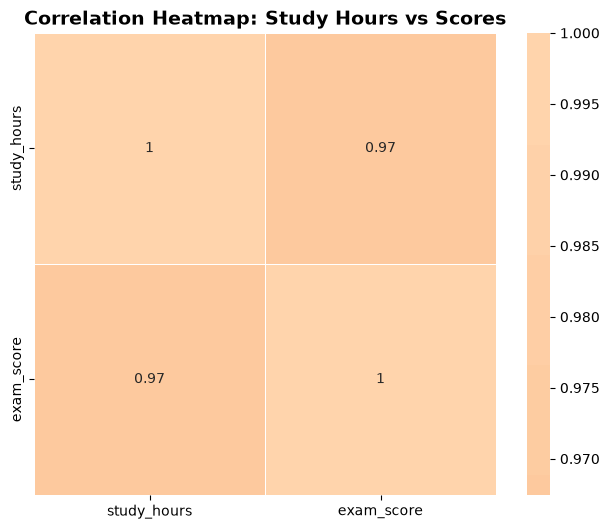


🎓 Summary of Learnings:
------------------------------
1. Linear Regression finds the 'Best Line' through data.
2. The Equation helps you predict 'Score' for any 'Study Hour'.
3. R-squared tells you how 'accurate' the fit is (0 to 1).
4. Correlation shows if variables move together or apart.


In [19]:
# Visualize correlation matrix using a Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, center=0, square=True, linewidths=0.5)

plt.title('Correlation Heatmap: Study Hours vs Scores', fontsize=14, fontweight='bold')
plt.show()

print("\n🎓 Summary of Learnings:")
print("-" * 30)
print("1. Linear Regression finds the 'Best Line' through data.")
print("2. The Equation helps you predict 'Score' for any 'Study Hour'.")
print("3. R-squared tells you how 'accurate' the fit is (0 to 1).")
print("4. Correlation shows if variables move together or apart.")


### 3. **Classification** - Putting things into Groups

While Regression predicts a **number**, **Classification** predicts a **group** or **category** (like "Pass" vs "Fail").

#### **Turning Text into Numbers (Encoding)**
Computers only understand numbers. To use words like "Low" or "High", we must **convert** them:

1. **Label Encoding**: Assigns a number to each word (e.g., `Pass = 1`, `Fail = 0`). Best for ranked data.
2. **One-Hot Encoding**: Creates new "Yes/No" columns for each category. Best for unrelated categories.

**Demo:** Converting student grades into numbers.


In [20]:
from sklearn.preprocessing import LabelEncoder

# Sample data with categories
data = pd.DataFrame({'Grade': ['Low', 'High', 'Medium', 'Low', 'High']})

# Option 1: Label Encoding
le = LabelEncoder()
data['Grade_Encoded'] = le.fit_transform(data['Grade'])

# Option 2: One-Hot Encoding (using Pandas)
one_hot = pd.get_dummies(data['Grade'], prefix='Is')

print("Original Data & Label Encoding:")
print(data)
print("\nOne-Hot Encoding:")
print(one_hot)


Original Data & Label Encoding:
    Grade  Grade_Encoded
0     Low              1
1    High              0
2  Medium              2
3     Low              1
4    High              0

One-Hot Encoding:
   Is_High  Is_Low  Is_Medium
0    False    True      False
1     True   False      False
2    False   False       True
3    False    True      False
4     True   False      False


### 4. **Evaluation Metrics** - How good is our guess?

In classification, we check how many times the model got the "Group" right.

**The Main Metrics:**
- **Accuracy**: Overall, how often was the model **right**?
- **Precision**: When it guessed **"Pass"**, how often was it **actually "Pass"**?
- **Recall**: Out of all **actual "Passes"**, how many did it **find**?
- **F1-Score**: A **balance** between Precision and Recall.

**Think of it like this:**
- **True Positive (TP)**: Model says "Pass", Student actually Passed. (Correct!)
- **False Positive (FP)**: Model says "Pass", but Student actually Failed. (Wrong!)


### 5. **Decision Tree** - The Rule-Based Learner

A **Decision Tree** works like a flow chart. It asks simple **Yes/No** questions to reach a conclusion.

**Process:**
1. **Dataset Curation**: Prepare data with patterns.
2. **Data Cleaning**: Remove **Missing (Null)** values or **Duplicates**.
3. **Train-Test Split**: Keep some data secret to **test** the model later.
4. **Fit & Predict**: Teach the model and make it guess.

**Demo:** predicting if a student will **Pass** or **Fail**.


In [21]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# 1. Create a raw dataset
raw_data = {
    'Study_Hours': [2, 8, 1, 10, 5, 8, 2, 8, np.nan, 10], # One missing value
    'Attendance_%': [40, 90, 30, 95, 60, 90, 40, 90, 70, 95], # One duplicate row
    'Result': ['Fail', 'Pass', 'Fail', 'Pass', 'Fail', 'Pass', 'Fail', 'Pass', 'Pass', 'Pass']
}
df_class = pd.DataFrame(raw_data)

# 2. Cleaning: Handle Null and Duplicates
df_class['Study_Hours'] = df_class['Study_Hours'].fillna(df_class['Study_Hours'].mean()) # Fill nulls
df_class = df_class.drop_duplicates() # Remove duplicates

# Encode Result to numbers
df_class['Result_Num'] = le.fit_transform(df_class['Result']) # Fail=0, Pass=1

# 3. Features (X) and Target (y)
X_clf = df_class[['Study_Hours', 'Attendance_%']]
y_clf = df_class['Result_Num']

# 4. Train-Test Split (80% for learning, 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

# 5. Training the Model
clf = DecisionTreeClassifier(max_depth=3)
clf.fit(X_train, y_train)




,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [22]:
# 6. Making Predictions
y_pred_clf = clf.predict(X_test)

print("Actual Results:", y_test.values)
print("Predicted Results:", y_pred_clf)
print(f"\nAccuracy Score: {accuracy_score(y_test, y_pred_clf)*100:.0f}%")

Actual Results: [0 1]
Predicted Results: [0 1]

Accuracy Score: 100%


In [23]:
# write random value prediction
new_data = np.array([[4, 80]])  # 4 study hours, 80% attendance
predicted_result = clf.predict(new_data)[0]

result_label = le.inverse_transform([predicted_result])[0]

print(f"Prediction for 4 study hours & 80% attendance: {result_label}")

Prediction for 4 study hours & 80% attendance: Fail


c:\Users\USER\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


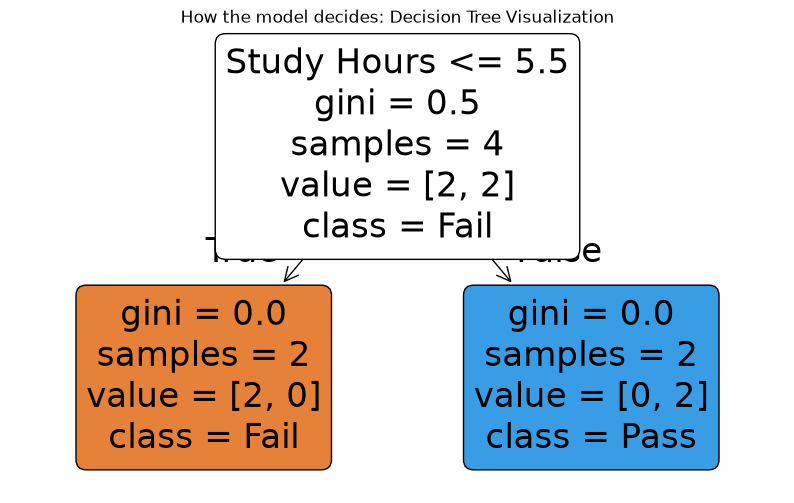

In [24]:
# 7. Visualizing the Decision Tree
plt.figure(figsize=(10, 6))
plot_tree(clf, 
          feature_names=['Study Hours', 'Attendance'], 
          class_names=['Fail', 'Pass'], 
          filled=True, 
          rounded=True)
plt.title("How the model decides: Decision Tree Visualization")
plt.show()


### 6. **Random Forest** - Safety in Numbers

Think of **Random Forest** as a team of many **Decision Trees** working together.

- **Why use it?** One tree might make a mistake, but a **Forest of Treees** takes a **vote**. 
- **Result**: The forest is usually much more **accurate** and **reliable** than a single tree.

**Summary**: 
- Use **Regression** for numbers (Price, Score).
- Use **Classification** for groups (Apple/Orange, Pass/Fail).


### 📚 **Learn More: Recommended Resources**

Ready to dive deeper? Here are some simple, beginner-friendly YouTube playlists:

#### **1. Machine Learning (ML)**
The big picture of teaching computers from data:
- **StatQuest with Josh Starmer**: Breaks down complex ML math into silly, simple songs and pictures. Highly recommended!
- **Sentdex - Practical ML**: A great hands-on playlist for learning how ML works with real Python code.
- **Krish Naik - ML for Beginners**: Clear explanations of almost every ML topic you'll ever need.

#### **2. Deep Learning (DL)**
Using **Neural Networks** (inspired by the human brain) for complex tasks like face recognition:
- **3Blue1Brown - Neural Networks**: The most beautiful visual explanation of how the "brain" of a computer works.
- **Codebasics - Deep Learning**: Starts from the absolute basics and explains things in very simple English.
- **CampusX - Deep Learning**: A very detailed and beginner-friendly road-map to mastering Deep Learning.

#### **3. Practice & Communities**
- **Kaggle**: The "playground" for data scientists. You can find free datasets and see how others solve problems.
- **FreeCodeCamp**: Often hosts multi-hour "full courses" on YouTube that take you from zero to hero in one video.

**Tip**: Don't try to learn everything at once. Pick one playlist that you enjoy and follow along by typing the code yourself!
